# Vocabulary

input: preprocessed datasets (TSV format)

Import libraries

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

Package installation

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Load preprocessed dataset

In [ ]:
year = 2022
category = 'politics'

df = pd.read_csv(f'/content/sample_data/pravda_preprocessed_{year}_{category}.tsv', sep='\t')
df


,url,category,title,lead,paragraphs,lemmatized_paragraphs
0,https://www.pravda.ru/news/politics/1776215-ro...,politics,Профессор Стрельцов: разговоры о российско-япо...,Предпосылок для подписаниямирного договорамежд...,Предпосылок для подписаниямирного договорамежд...,предпосылка подписаниямирного договорамежду ро...
1,https://www.pravda.ru/news/politics/1699578-gl...,politics,"Глава МИД Украины Кулеба заявил, что Мариуполя...",Сегодня был определяющий день для Мариуполя и ...,Сегодня был определяющий день для Мариуполя и ...,сегодня определять день мариуполь металлургиче...
2,https://www.pravda.ru/news/politics/1685503-ev...,politics,"Евросоюз ""пожалел"" заразившегося коронавирусом...","Лидер ЛДПРВладимир Жириновский, который проход...","Лидер ЛДПРВладимир Жириновский, который проход...",лидер лдпрвладимир жириновский проходить лечен...
3,https://www.pravda.ru/news/politics/1778521-ge...,politics,За геноцид ФРГ и Франция задолжала жителям Дон...,На фоне признания экс-канцлера ГерманииАнгелы ...,На фоне признания экс-канцлера ГерманииАнгелы ...,фон признание экс канцлер германииангелы мерке...
4,https://www.pravda.ru/politics/1749069-dmitrii...,politics,Сбежавший за границу экс-депутат предложил пер...,"Бывший депутат ГосдумыДмитрий Гудковсчитает, ч...","Бывший депутат ГосдумыДмитрий Гудковсчитает, ч...",бывший депутат госдумыдмитрий гудковсчитает ро...
...,...,...,...,...,...,...
2101,https://www.pravda.ru/news/politics/1765631-sa...,politics,Сатановский: я бы предложил кастрировать чинов...,Востоковед и политологЕвгений Сатановскийрасск...,Востоковед и политологЕвгений Сатановскийрасск...,востоковед политологевгений сатановскийрассказ...
2102,https://www.pravda.ru/news/politics/1743487-vi...,politics,"РФ пригрозила ЕС ""неизбежным ответом"" на замор...",Россия неизбежно ответит назаморозку соглашени...,Россия неизбежно ответит назаморозку соглашени...,россия неизбежно ответить назаморозку соглашен...
2103,https://www.pravda.ru/news/politics/1689077-al...,politics,Сосновский: против российских солдат будет исп...,"Немецкий политологАлександр Сосновскийсчитает,...","Немецкий политологАлександр Сосновскийсчитает,...",немецкий политологалександр сосновскийсчитает ...
2104,https://www.pravda.ru/politics/1770683-horoshua/,politics,"Украина назвала россиян, которых хочет видеть ...","Украинские эксперты обнародовалисписки ""хороши...","Украинские эксперты обнародовалисписки ""хороши...",украинские эксперт обнародовалисписка хороший ...


Count lemmas

In [ ]:
documents = df['lemmatized_paragraphs'].to_list()

# Initialize a Counter object
lemmas = Counter()

# Count tokens across all documents
for document in documents:
  tokens = word_tokenize(document)
  lemmas.update(tokens)

Total lemmas

In [ ]:
sum(lemmas.values())

230803

In [ ]:
with open('/content/sample_data/pravda_preprocessed_2022_politics.tsv', 'r', encoding='utf-8') as file:
    for i, line in enumerate(file):
        if i == 457:
            print(line)


https://www.pravda.ru/politics/1673837-kasparov/	politics	"Каспаров объявил об ""оккупации Казахстана"""	"Бывший чемпион мира по шахматам, ныне гражданин ХорватииГарри Каспаровзаявил об ""оккупации Казахстана"". А кроме того, ещё и обвинил премьер-министра АрменииНикола Пашинянав соучастии ""в массовых убийствах в Казахстане""."	"Бывший чемпион мира по шахматам, ныне гражданин ХорватииГарри Каспаровзаявил об ""оккупации Казахстана"". А кроме того, ещё и обвинил премьер-министра АрменииНикола Пашинянав соучастии ""в массовых убийствах в Казахстане"". ""Позорным на этом фоне выглядит поведение армянского лидера Никола Пашиняна, принявшего деятельное участие в реализации плана по оккупации Казахстана, став тем самым соучастником сегодняшних массовых убийств. То обстоятельство, что Пашинян пришёл к власти в результате мирной революции, делает его действия особо циничными. Невозможно купить безопасность собственного народа ценой крови других народов"", — цитирует Гарри Каспарова азербайджан

Unique lemmas

In [ ]:
len(lemmas)

26763

Ratio

In [ ]:
len(lemmas) / sum(lemmas.values())

0.11595603176735138

Get most frequent words

In [ ]:
top_n = 30
most_common = lemmas.most_common(top_n)
most_common

[('россия', 3589),
 ('украина', 2790),
 ('российский', 1974),
 ('страна', 1743),
 ('слово', 1249),
 ('президент', 1236),
 ('сша', 1209),
 ('год', 1187),
 ('рф', 1108),
 ('заявить', 1082),
 ('военный', 1074),
 ('глава', 910),
 ('запад', 762),
 ('человек', 748),
 ('москва', 736),
 ('подчеркнуть', 729),
 ('сказать', 690),
 ('время', 689),
 ('мнение', 685),
 ('отметить', 666),
 ('киев', 644),
 ('путин', 624),
 ('власть', 605),
 ('вопрос', 598),
 ('территория', 583),
 ('нато', 579),
 ('эксперт', 555),
 ('представитель', 555),
 ('считать', 552),
 ('американский', 552)]

Plot the most frequent words

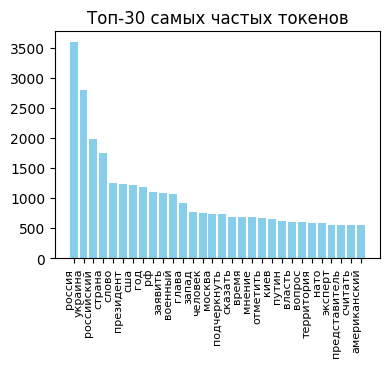

In [ ]:
tokens, counts = zip(*most_common)   # Unzip into tokens and counts

# Create a bar plot
plt.figure(figsize=(4, 4))
plt.bar(tokens, counts, color='skyblue')
plt.title(f'Топ-{top_n} самых частых токенов')
plt.xticks(rotation=90, ha='right')  # Rotate token labels for readability
plt.tight_layout()                   # Adjust layout to prevent label cutoff
plt.xticks(fontsize=8)               # Y-axis tick labels font size
plt.show()